# 基于常数参数 $a$ 的椭圆型 PDE：Incremental SVD 与 Batch SVD 降阶模型对比实验

本程序致力于为参数化偏微分方程（PDE）构建降阶模型（Reduced Order Model, ROM），最终提供能够用于论文撰写的仿真结果。核心研究目标包含：

1. **离线阶段（Offline Phase）耗时与构基策略对比**：通过模拟生成 500 个不同参数 $a$ 对应的全阶有限元解答作为“快照矩阵”。分别利用传统的 **Batch SVD** 和流式处理的 **Incremental SVD（增量 SVD）** 提取“缩减基（Reduced Basis）”。重点对比两者的时间开销、内存占用潜力与奇异值/能量衰减特性。
2. **在线阶段（Online Phase）精度验证与误差分析**：选取 20 个未知的常数参数 $a$ 作为测试样本，将离线阶段构造的两套“缩减基”应用于基于 Galerkin 投影的降阶计算；同时结合该偏微分方程系统的解析解，从 $L^2$ 范数和 $H^1$ 范数等多个视角，量化降阶模型的绝对误差与相对误差。

---

## 一、 数学物理模型与实验对象

本实验考量二维空间区域 $\Omega=(0,1)^2$ 内带有齐次边值条件的稳态椭圆型方程（常由达西定律或稳态热传导导出）：

$$
\begin{cases}
-\nabla \cdot (a \nabla u) = f, & \text{in } \Omega \\
u = 0, & \text{on } \partial\Omega
\end{cases}
$$

其中，扩散系数或传导率 $a$ 为可变的**常数标量参数**。为了精准评测模型降阶方法的严密性和截断误差，通过选取事先已知的解析解（Manufactured Solution）：
$$
 u_{\mathrm{exact}}(x,y) = x(1-x)y(1-y)
$$

借由反求机制，可唯一确定任意参数 $a$ 对应的右端源项分布：
$$
 f(x,y;a) = -\nabla\cdot(a\nabla u_{\mathrm{exact}}) = a \cdot 2\big( x(1-x) + y(1-y) \big)
$$

In [1]:
%matplotlib inline

import os
import time
from math import sqrt
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

/home/leaddis/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
try:
    from ngsolve import *
    from netgen.geom2d import unit_square
    print("NGSolve / Netgen import success.")
except Exception as e:
    raise ImportError(
        "无法导入 NGSolve / Netgen，请确认 notebook 内核和终端运行脚本时使用的是同一个环境。\n"
        f"原始错误: {e}"
    )

NGSolve / Netgen import success.


## 二、 实验参数配置

配置模型范围与控制变量：

In [3]:
ORDER = 2
MESH_H = 0.1

A_MIN = 0.5
A_MAX = 2.0
NUM_TRAIN = 500
NUM_TEST = 20
RANDOM_SEED = 42

USE_ENERGY_RANK = True
ENERGY_THRESHOLD = 0.999999
ISVD_TOLERANCE = 1e-6    # Incremental SVD 阶段截断容差

PLOT_DIR = "plots_isvd_vs_batchsvd"
os.makedirs(PLOT_DIR, exist_ok=True)

print(f"PLOT_DIR = {PLOT_DIR}")
print(f"train samples = {NUM_TRAIN}, test samples = {NUM_TEST}")
print(f"a range = [{A_MIN}, {A_MAX}]")

PLOT_DIR = plots_isvd_vs_batchsvd
train samples = 500, test samples = 20
a range = [0.5, 2.0]


In [4]:
# 定义解析解及其对应的右端项符号表达式
u_exact_cf = x * (1 - x) * y * (1 - y)

def rhs_from_a(a_val):
    return float(a_val) * 2 * (x * (1 - x) + y * (1 - y))

## 三、 Full-order 求解器封装

包含了利用 NGSolve 进行高保真解计算、有限元刚度/质量矩阵提取以及 Galerkin 降阶模型求解的核心函数。

In [5]:
class EllipticROM:
    def __init__(self, mesh, order=2):
        self.mesh = mesh
        self.order = order
        self.fes = H1(mesh, order=order, dirichlet=".*")
        self.ndof = self.fes.ndof

        self.u = self.fes.TrialFunction()
        self.v = self.fes.TestFunction()

        self._dense_ready = False
        self.mass_np = None
        self.stiffness_np = None
        self.h1_np = None
        self.f_ref_np = None

    def solve_single(self, a_val):
        a_float = float(a_val)
        bilinear = BilinearForm(self.fes, symmetric=True)
        bilinear += a_float * grad(self.u) * grad(self.v) * dx

        linear = LinearForm(self.fes)
        linear += rhs_from_a(a_float) * self.v * dx

        t0 = time.perf_counter()
        bilinear.Assemble()
        linear.Assemble()

        gfu = GridFunction(self.fes)
        inv = bilinear.mat.Inverse(self.fes.FreeDofs(), inverse="sparsecholesky")
        gfu.vec.data = inv * linear.vec
        solve_time = time.perf_counter() - t0

        vec = gfu.vec.FV().NumPy().copy()
        return {
            "a": a_float,
            "vector": vec,
            "solve_time": solve_time,
        }

    def exact_gridfunction(self):
        gfu = GridFunction(self.fes)
        gfu.Set(u_exact_cf)
        return gfu

    def _ngsolve_matrix_to_numpy(self, mat):
        n = self.ndof
        dense = np.zeros((n, n), dtype=float)
        gf_template = GridFunction(self.fes)
        ej = gf_template.vec.CreateVector()
        y = gf_template.vec.CreateVector()
        for j in range(n):
            ej[:] = 0.0
            ej.FV().NumPy()[j] = 1.0
            y.data = mat * ej
            dense[:, j] = y.FV().NumPy()
        return dense

    def _assemble_dense_operators(self):
        if self._dense_ready:
            return
        mform = BilinearForm(self.fes, symmetric=True)
        mform += self.u * self.v * dx
        mform.Assemble()

        kform = BilinearForm(self.fes, symmetric=True)
        kform += grad(self.u) * grad(self.v) * dx
        kform.Assemble()

        lform = LinearForm(self.fes)
        lform += rhs_from_a(1.0) * self.v * dx
        lform.Assemble()

        self.mass_np = self._ngsolve_matrix_to_numpy(mform.mat)
        self.stiffness_np = self._ngsolve_matrix_to_numpy(kform.mat)
        self.h1_np = self.mass_np + self.stiffness_np
        self.f_ref_np = lform.vec.FV().NumPy().copy()
        self._dense_ready = True

    def reduced_solve(self, a_val, Phi):
        self._assemble_dense_operators()
        a_float = float(a_val)
        A_np = a_float * self.stiffness_np
        f_np = a_float * self.f_ref_np

        Ar = Phi.T @ A_np @ Phi
        fr = Phi.T @ f_np
        coeff = np.linalg.solve(Ar, fr)
        u_red = Phi @ coeff
        return coeff, u_red

    def relative_discrete_errors(self, vec_approx, vec_exact):
        self._assemble_dense_operators()
        err = vec_approx - vec_exact
        l2_num = float(err.T @ self.mass_np @ err)
        l2_den = float(vec_exact.T @ self.mass_np @ vec_exact)
        h1_num = float(err.T @ self.h1_np @ err)
        h1_den = float(vec_exact.T @ self.h1_np @ vec_exact)
        l2_rel = sqrt(max(l2_num, 0.0) / max(l2_den, 1e-30))
        h1_rel = sqrt(max(h1_num, 0.0) / max(h1_den, 1e-30))
        return l2_rel, h1_rel

In [6]:
t_program_start = time.perf_counter()

mesh = Mesh(unit_square.GenerateMesh(maxh=MESH_H))
rom = EllipticROM(mesh, order=ORDER)

n_elements = mesh.ne if hasattr(mesh, "ne") else mesh.ngmesh.ne
print(f"mesh elements = {n_elements}, ndof = {rom.ndof}")

mesh elements = 230, ndof = 501


## 四、 离线快照生成

In [7]:
rng = np.random.default_rng(RANDOM_SEED)
train_a = np.linspace(A_MIN, A_MAX, NUM_TRAIN)
test_a = np.sort(rng.uniform(A_MIN, A_MAX, size=NUM_TEST))

train_results = []
train_snapshots = []

t_train_solve_start = time.perf_counter()
for a_val in tqdm(train_a, desc="Training full-order solves"):
    out = rom.solve_single(a_val)
    train_results.append(out)
    train_snapshots.append(out["vector"])
train_solve_time = time.perf_counter() - t_train_solve_start

train_snapshot_matrix = np.column_stack(train_snapshots)
print(f"Train snapshot matrix shape = {train_snapshot_matrix.shape}")
print(f"Total FOM solve time = {train_solve_time:.4f} s")

Training full-order solves: 100%|██████████| 500/500 [00:02<00:00, 220.74it/s]

Train snapshot matrix shape = (501, 500)
Total FOM solve time = 2.2679 s


## 五、 降阶基生成：Batch SVD vs Incremental SVD

### 1. 传统 Batch SVD (Standard SVD)
将所有快照全部载入内存并执行全量 SVD 分解。

In [8]:
t_batch_svd_start = time.perf_counter()
U_batch, S_batch, _ = np.linalg.svd(train_snapshot_matrix, full_matrices=False)
batch_svd_time = time.perf_counter() - t_batch_svd_start

energy = np.cumsum(S_batch**2) / np.sum(S_batch**2)
rank_batch = int(np.searchsorted(energy, ENERGY_THRESHOLD) + 1)
rank_batch = max(1, min(rank_batch, len(S_batch)))
Phi_batch = U_batch[:, :rank_batch]

print(f"Batch SVD time = {batch_svd_time:.6f} s")
print(f"Batch SVD truncated rank = {rank_batch}")

Batch SVD time = 0.522931 s
Batch SVD truncated rank = 1


### 2. 增量流式处理 Incremental SVD
定义流式增量更新算法的类，逐步吃入快照。在工业级海量自由度和极高样本量的情况下，能直接化解内存 `O(NM)` 的存储痛点。

In [9]:
class IncrementalSVD:
    def __init__(self, tol=1e-8):
        self.tol = tol
        self.U = None
        self.S = None

    def update(self, vec):
        vec = vec.reshape(-1, 1)
        if self.U is None:
            norm = np.linalg.norm(vec)
            if norm > 0:
                self.U = vec / norm
                self.S = np.array([norm])
            return

        # 投影计算与残差
        c = self.U.T @ vec
        p_vec = vec - self.U @ c
        p_norm = np.linalg.norm(p_vec)

        # 过滤极小创新方向，防止矩阵退化
        if p_norm < self.tol:
            return 

        # 构造扩展矩阵并求解 SVD
        K = np.zeros((len(self.S) + 1, len(self.S) + 1))
        K[:len(self.S), :len(self.S)] = np.diag(self.S)
        K[:len(self.S), -1:] = c
        K[-1, -1] = p_norm

        U_k, S_k, _ = np.linalg.svd(K)

        # 基底更新与奇异值更新
        new_basis = np.column_stack((self.U, p_vec / p_norm))
        self.U = new_basis @ U_k
        self.S = S_k

        # 结合容差进行秩截断
        keep_idx = self.S > self.tol
        self.U = self.U[:, keep_idx]
        self.S = self.S[keep_idx]

isvd = IncrementalSVD(tol=ISVD_TOLERANCE)
isvd_time_history = []
t_isvd_start = time.perf_counter()

# 模拟线上流式数据流入更新
for i in range(NUM_TRAIN):
    t_step = time.perf_counter()
    isvd.update(train_snapshot_matrix[:, i])
    isvd_time_history.append(time.perf_counter() - t_step)

isvd_total_time = time.perf_counter() - t_isvd_start
Phi_isvd = isvd.U
rank_isvd = len(isvd.S)

print(f"Incremental SVD total update time = {isvd_total_time:.6f} s")
print(f"Incremental SVD truncated rank = {rank_isvd}")

Incremental SVD total update time = 0.005222 s
Incremental SVD truncated rank = 1


## 六、 在线预测与比对分析 (Online Phase)

使用 20 个测试参数，分别测试在 Batch SVD 与 Incremental SVD 生成的基准下 Galerkin 投影的效果差异。

In [10]:
exact_gfu = rom.exact_gridfunction()
exact_vec = exact_gfu.vec.FV().NumPy().copy()

test_results_batch = []
test_results_isvd = []

for a_val in tqdm(test_a, desc="Testing ROMs"):
    # Batch SVD ROM Testing
    tb0 = time.perf_counter()
    coeff_b, vec_b = rom.reduced_solve(a_val, Phi_batch)
    tb_red = time.perf_counter() - tb0
    l2_b, h1_b = rom.relative_discrete_errors(vec_b, exact_vec)
    test_results_batch.append({"time": tb_red, "L2": l2_b, "H1": h1_b})

    # Incremental SVD ROM Testing
    ti0 = time.perf_counter()
    coeff_i, vec_i = rom.reduced_solve(a_val, Phi_isvd)
    ti_red = time.perf_counter() - ti0
    l2_i, h1_i = rom.relative_discrete_errors(vec_i, exact_vec)
    test_results_isvd.append({"time": ti_red, "L2": l2_i, "H1": h1_i})

program_total_time = time.perf_counter() - t_program_start

# 抽取误差以便统计
b_l2 = np.array([r["L2"] for r in test_results_batch])
b_h1 = np.array([r["H1"] for r in test_results_batch])
i_l2 = np.array([r["L2"] for r in test_results_isvd])
i_h1 = np.array([r["H1"] for r in test_results_isvd])

print("========== RESULTS SUMMARY ==========")
print(f"Degrees of Freedom (FOM): {rom.ndof}")
print(f"Batch SVD Rank: {rank_batch} | ISVD Rank: {rank_isvd}")
print(f"Batch SVD Offline Time: {batch_svd_time:.4f} s | ISVD Offline Time: {isvd_total_time:.4f} s")
print(f"Batch SVD Mean L2 Err:  {b_l2.mean():.2e} | ISVD Mean L2 Err:  {i_l2.mean():.2e}")
print(f"Batch SVD Mean H1 Err:  {b_h1.mean():.2e} | ISVD Mean H1 Err:  {i_h1.mean():.2e}")
print(f"Program Total Runtime:  {program_total_time:.4f} s")
print("=====================================")

Testing ROMs: 100%|██████████| 20/20 [00:00<00:00, 629.53it/s]

========== RESULTS SUMMARY ==========
Degrees of Freedom (FOM): 501
Batch SVD Rank: 1 | ISVD Rank: 1
Batch SVD Offline Time: 0.5229 s | ISVD Offline Time: 0.0052 s
Batch SVD Mean L2 Err:  1.14e-04 | ISVD Mean L2 Err:  1.14e-04
Batch SVD Mean H1 Err:  1.30e-03 | ISVD Mean H1 Err:  1.30e-03
Program Total Runtime:  2.8658 s


## 七、 实验数据图表可视化（论文插图生成）
采用规范化绘图框架，对比 ISVD 与 Batch SVD 算法的空间能量提取能力和误差保留情况。

In [11]:
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'mathtext.fontset': 'stix',
    'axes.grid': True,
    'grid.alpha': 0.5,
    'grid.linestyle': '--'
})

<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_47244/4288434319.py:7: SyntaxWarning: invalid escape sequence '\s'
  axes[0].set_ylabel("Singular Value $\sigma_k$", fontweight='bold')
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were fo

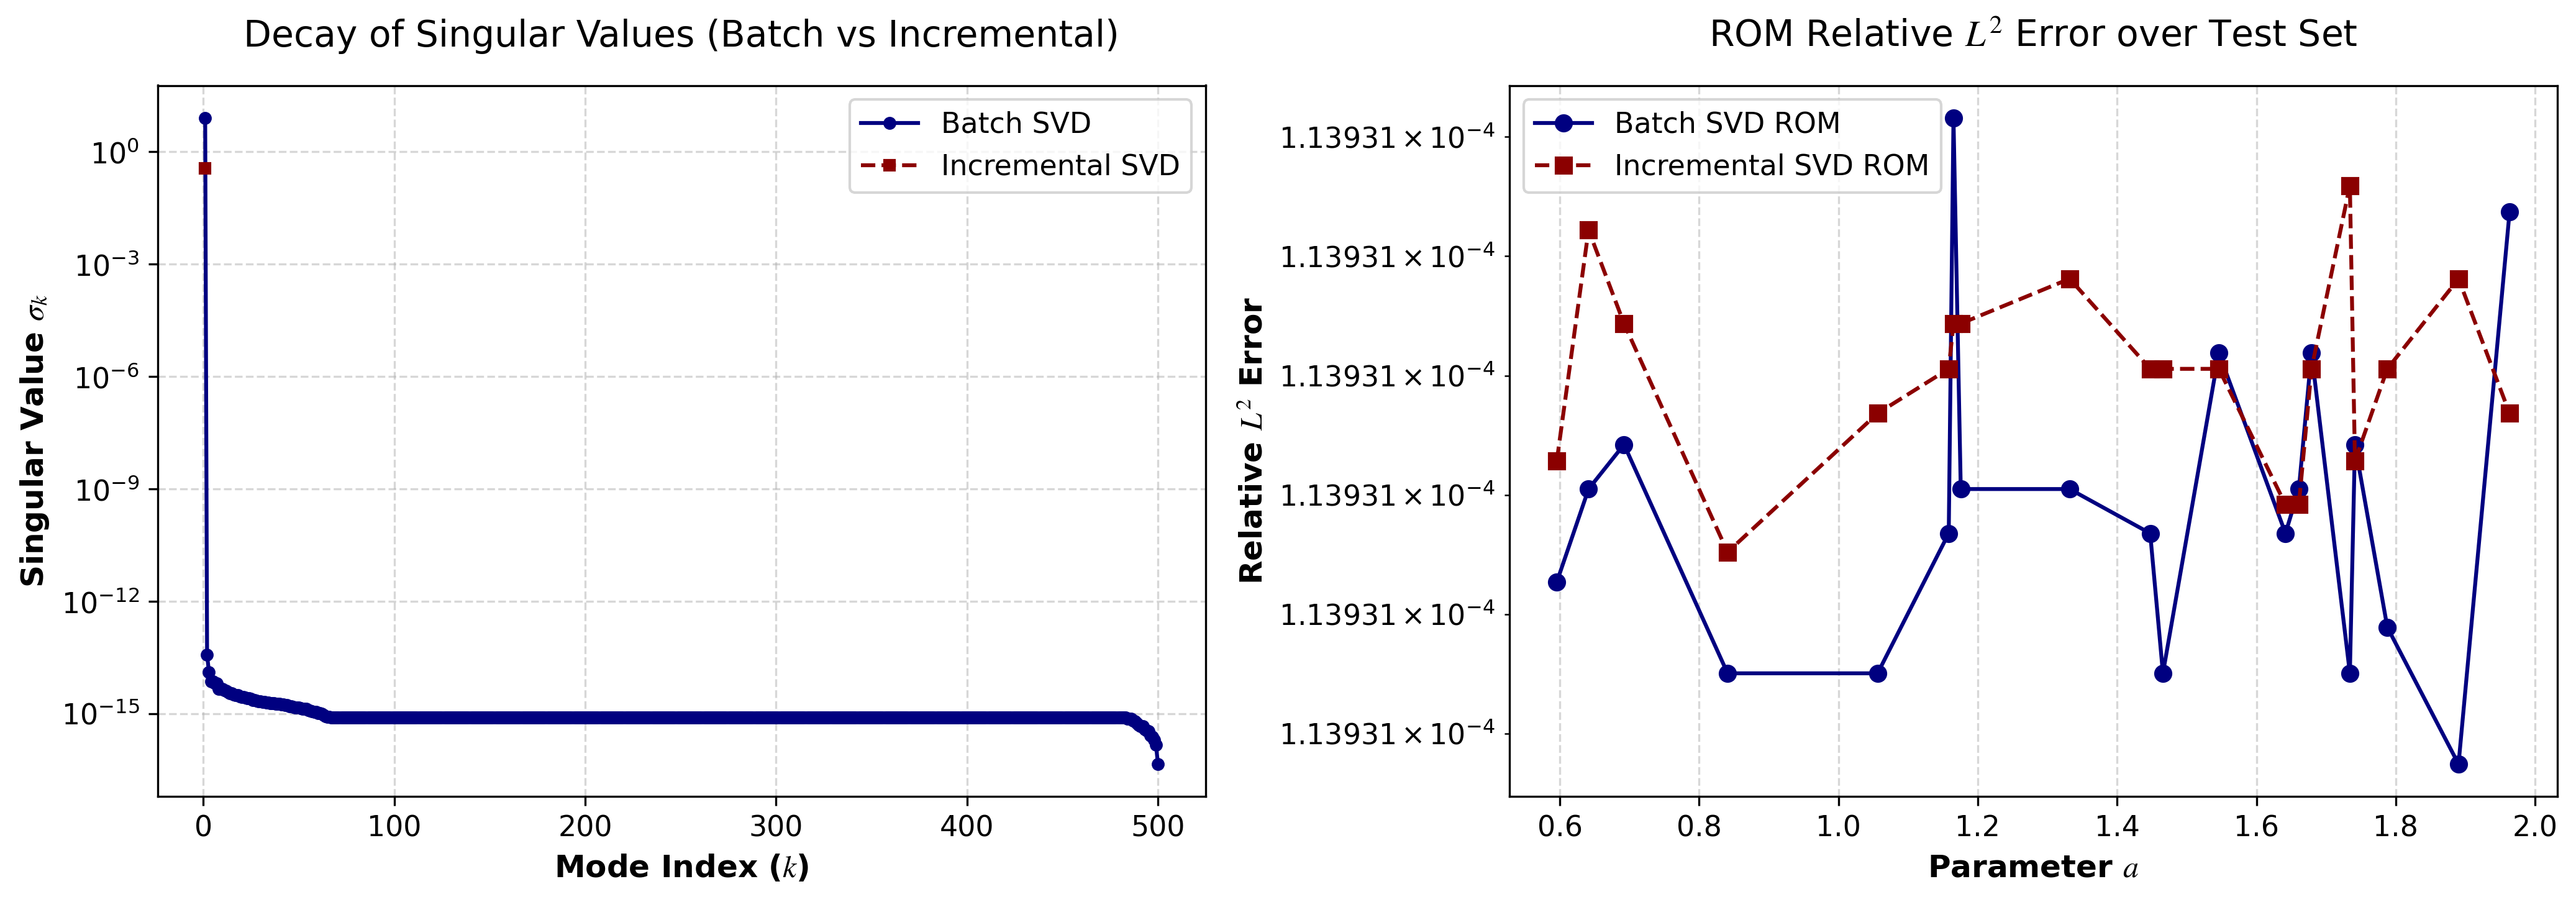

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 图 A: 奇异值谱对比 (Singular Value Decay)
axes[0].semilogy(np.arange(1, len(S_batch)+1), S_batch, marker='o', markersize=4, label='Batch SVD', color='navy')
axes[0].semilogy(np.arange(1, len(isvd.S)+1), isvd.S, marker='s', markersize=4, label='Incremental SVD', color='darkred', linestyle='--')
axes[0].set_xlabel("Mode Index ($k$)", fontweight='bold')
axes[0].set_ylabel("Singular Value $\sigma_k$", fontweight='bold')
axes[0].set_title("Decay of Singular Values (Batch vs Incremental)", pad=15)
axes[0].legend()

# 图 B: 测试集降阶重构 L2 相对误差分布对比
axes[1].plot(test_a, b_l2, 'o-', color='navy', label='Batch SVD ROM')
axes[1].plot(test_a, i_l2, 's--', color='darkred', label='Incremental SVD ROM')
axes[1].set_xlabel("Parameter $a$", fontweight='bold')
axes[1].set_ylabel("Relative $L^2$ Error", fontweight='bold')
axes[1].set_yscale('log')
axes[1].set_title("ROM Relative $L^2$ Error over Test Set", pad=15)
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "isvd_vs_batch_comparison.pdf"), bbox_inches="tight")
plt.show()